# Kalman Filter P Sweep Analysis

Analyzes `p_{0,250,400}_q_{05,10}_r_measurement_45_{extend,retract}_100ms.csv` — the same
R-measurement runs as the Q sweep, but now with three feedforward/setpoint gain values
`P = 0, 250, 400` (the un-prefixed `q_{05,10}_...` files are `P = 250`, the un-annotated
baseline), at each of the two `sigma_v_sq` (Q) settings already explored.

Goal: quantify how the post-fit residual (`position_reading - position_estimate`) and velocity
estimate respond as **P** increases, at fixed Q, to see whether P has any effect on filter/tracking
noise (as opposed to Q, which is the filter tuning knob) — i.e. sanity-check that P is doing what
a feedforward/setpoint term should (change the response speed) without blowing up estimation noise.

**Correction:** the position measurement in these logs is 10x too large (units/calibration
error upstream). `POSITION_SCALE` below corrects `position_reading`, `position_estimate`, and
`velocity_estimate` (which inherits the error since velocity = d(position)/dt) at load time, so
`residual` and `raw_velocity` — both derived from these columns — come out correctly scaled
automatically, and every downstream cell (summary table, trend plots, traces, verdict) uses the
corrected values without further changes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)

DATA_DIR = './'
POSITION_SCALE = 1 / 10  # position_reading was logged 10x too large; corrects position & velocity

# P = 250 is the non-annotated baseline (files with no p_ prefix)
P_FILES = {
    'p0_q5_extend':    'p_0_q_05_r_measurement_45_extend_100ms.csv',
    'p0_q5_retract':   'p_0_q_05_r_measurement_45_retract_100ms.csv',
    'p0_q10_extend':   'p_0_q_10_r_measurement_45_extend_100ms.csv',
    'p0_q10_retract':  'p_0_q_10_r_measurement_45_retract_100ms.csv',

    'p250_q5_extend':   'q_05_r_measurement_45_extend_100ms.csv',
    'p250_q5_retract':  'q_05_r_measurement_45_retract_100ms.csv',
    'p250_q10_extend':  'q_10_r_measurement_45_extend_100ms.csv',
    'p250_q10_retract': 'q_10_r_measurement_45_retract_100ms.csv',

    'p400_q5_extend':   'p_400_q_05_r_measurement_45_extend_100ms.csv',
    'p400_q5_retract':  'p_400_q_05_r_measurement_45_retract_100ms.csv',
    'p400_q10_extend':  'p_400_q_10_r_measurement_45_extend_100ms.csv',
    'p400_q10_retract': 'p_400_q_10_r_measurement_45_retract_100ms.csv',
}

P_VALUE_OF = {name: float(name.split('_')[0][1:]) for name in P_FILES}
Q_VALUE_OF = {name: (5.0 if 'q5' in name else 10.0) for name in P_FILES}

def load_p(fname):
    # Files are UTF-16 (BOM) encoded, comma-separated, with spaces after commas in the header.
    df = pd.read_csv(DATA_DIR + fname, encoding='utf-16')
    df.columns = [c.strip() for c in df.columns]
    for col in ['position_reading', 'position_estimate', 'velocity_estimate']:
        df[col] = df[col] * POSITION_SCALE
    df['residual'] = df['position_reading'] - df['position_estimate']
    df['raw_velocity'] = df['position_reading'].diff() / df['delta_t']
    return df

p_data = {name: load_p(f) for name, f in P_FILES.items()}
{name: len(df) for name, df in p_data.items()}

{'p0_q5_extend': 265,
 'p0_q5_retract': 364,
 'p0_q10_extend': 289,
 'p0_q10_retract': 430,
 'p250_q5_extend': 344,
 'p250_q5_retract': 359,
 'p250_q10_extend': 362,
 'p250_q10_retract': 571,
 'p400_q5_extend': 317,
 'p400_q5_retract': 321,
 'p400_q10_extend': 304,
 'p400_q10_retract': 554}

## 1. Residual and velocity summary per (P, Q) run

In [2]:
def lag_autocorr(x, lag=1):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    return np.sum(x[:-lag] * x[lag:]) / np.sum(x**2)

p_rows = []
for name, df in p_data.items():
    r = df['residual'].values
    p_rows.append({
        'run': name,
        'P': P_VALUE_OF[name],
        'Q (sigma_v_sq)': Q_VALUE_OF[name],
        'direction': 'extend' if 'extend' in name else 'retract',
        'n': len(df),
        'resid_std': r.std(),
        'resid_ac1': lag_autocorr(r, 1),
        'vel_est_std': df['velocity_estimate'].std(),
        'raw_vel_std': df['raw_velocity'].std(),
    })
p_summary = pd.DataFrame(p_rows).set_index('run')
p_summary.round(4)

,P,Q (sigma_v_sq),direction,n,resid_std,resid_ac1,vel_est_std,raw_vel_std
run,,,,,,,,
p0_q5_extend,0.0,5.0,extend,265,0.1796,0.9573,1.6686,1.6746
p0_q5_retract,0.0,5.0,retract,364,0.2264,0.9593,1.7021,1.6652
p0_q10_extend,0.0,10.0,extend,289,0.1561,0.9470,1.7012,1.6941
p0_q10_retract,0.0,10.0,retract,430,0.1629,0.9436,1.6438,1.6106
p250_q5_extend,250.0,5.0,extend,344,0.0717,0.9333,1.6660,1.6805
p250_q5_retract,250.0,5.0,retract,359,0.0602,0.9302,1.6939,1.6726
p250_q10_extend,250.0,10.0,extend,362,0.0538,0.9051,1.6582,1.6680
p250_q10_retract,250.0,10.0,retract,571,0.0365,0.8978,1.5077,1.4848
p400_q5_extend,400.0,5.0,extend,317,0.0820,0.8663,1.7298,1.6898


**Reading this table:**
- `resid_std` — how far the raw reading typically sits from the filter's estimate. Since P is a
  setpoint/feedforward gain (not a filter parameter), we'd expect `resid_std` to stay roughly flat
  across P at fixed Q — if it instead trends with P, that means the actuator's dynamics or the
  measurement noise itself are changing with the drive strength (e.g. a stronger/faster stroke
  producing more mechanical noise or sensor slew error).
- `resid_ac1` — lag-1 autocorrelation of the residual. Same logic: a real Q effect should be
  Q-dependent, not P-dependent. A trend with P is a symptom of the plant, not the filter.
- `vel_est_std` vs `raw_vel_std` — sanity check that the filter isn't amplifying noise; also lets
  us see if higher P (faster strokes) simply produces a genuinely higher raw velocity, which is
  expected and not itself a red flag.

## 2. Trend: std metrics vs P (faceted by Q)

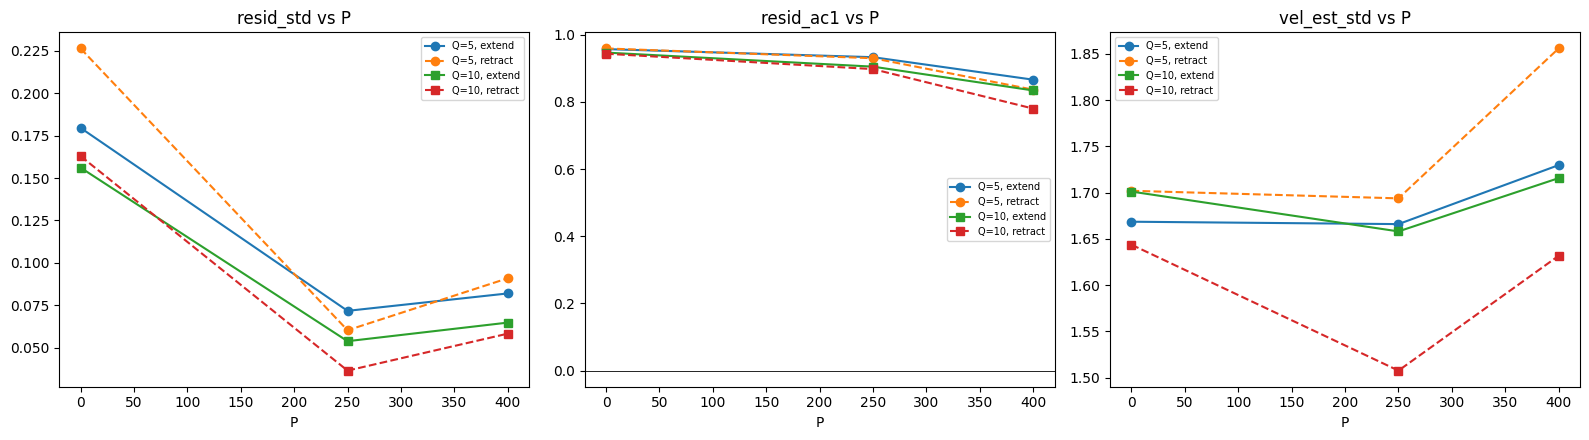

In [3]:
p_sorted = sorted(set(P_VALUE_OF.values()))
q_values = sorted(set(Q_VALUE_OF.values()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
styles = {5.0: ('o-', 'o--'), 10.0: ('s-', 's--')}

for q in q_values:
    marker_ext, marker_ret = styles[q]
    for direction, marker in zip(['extend', 'retract'], [marker_ext, marker_ret]):
        sub = p_summary[(p_summary['direction'] == direction) & (p_summary['Q (sigma_v_sq)'] == q)]
        sub = sub.sort_values('P')
        label = f'Q={q:g}, {direction}'
        axes[0].plot(sub['P'], sub['resid_std'], marker, label=label)
        axes[1].plot(sub['P'], sub['resid_ac1'], marker, label=label)
        axes[2].plot(sub['P'], sub['vel_est_std'], marker, label=label)

axes[0].set_title('resid_std vs P'); axes[0].set_xlabel('P')
axes[1].set_title('resid_ac1 vs P'); axes[1].set_xlabel('P'); axes[1].axhline(0, color='k', lw=0.6)
axes[2].set_title('vel_est_std vs P'); axes[2].set_xlabel('P')
for ax in axes:
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 3. Position and velocity traces per run

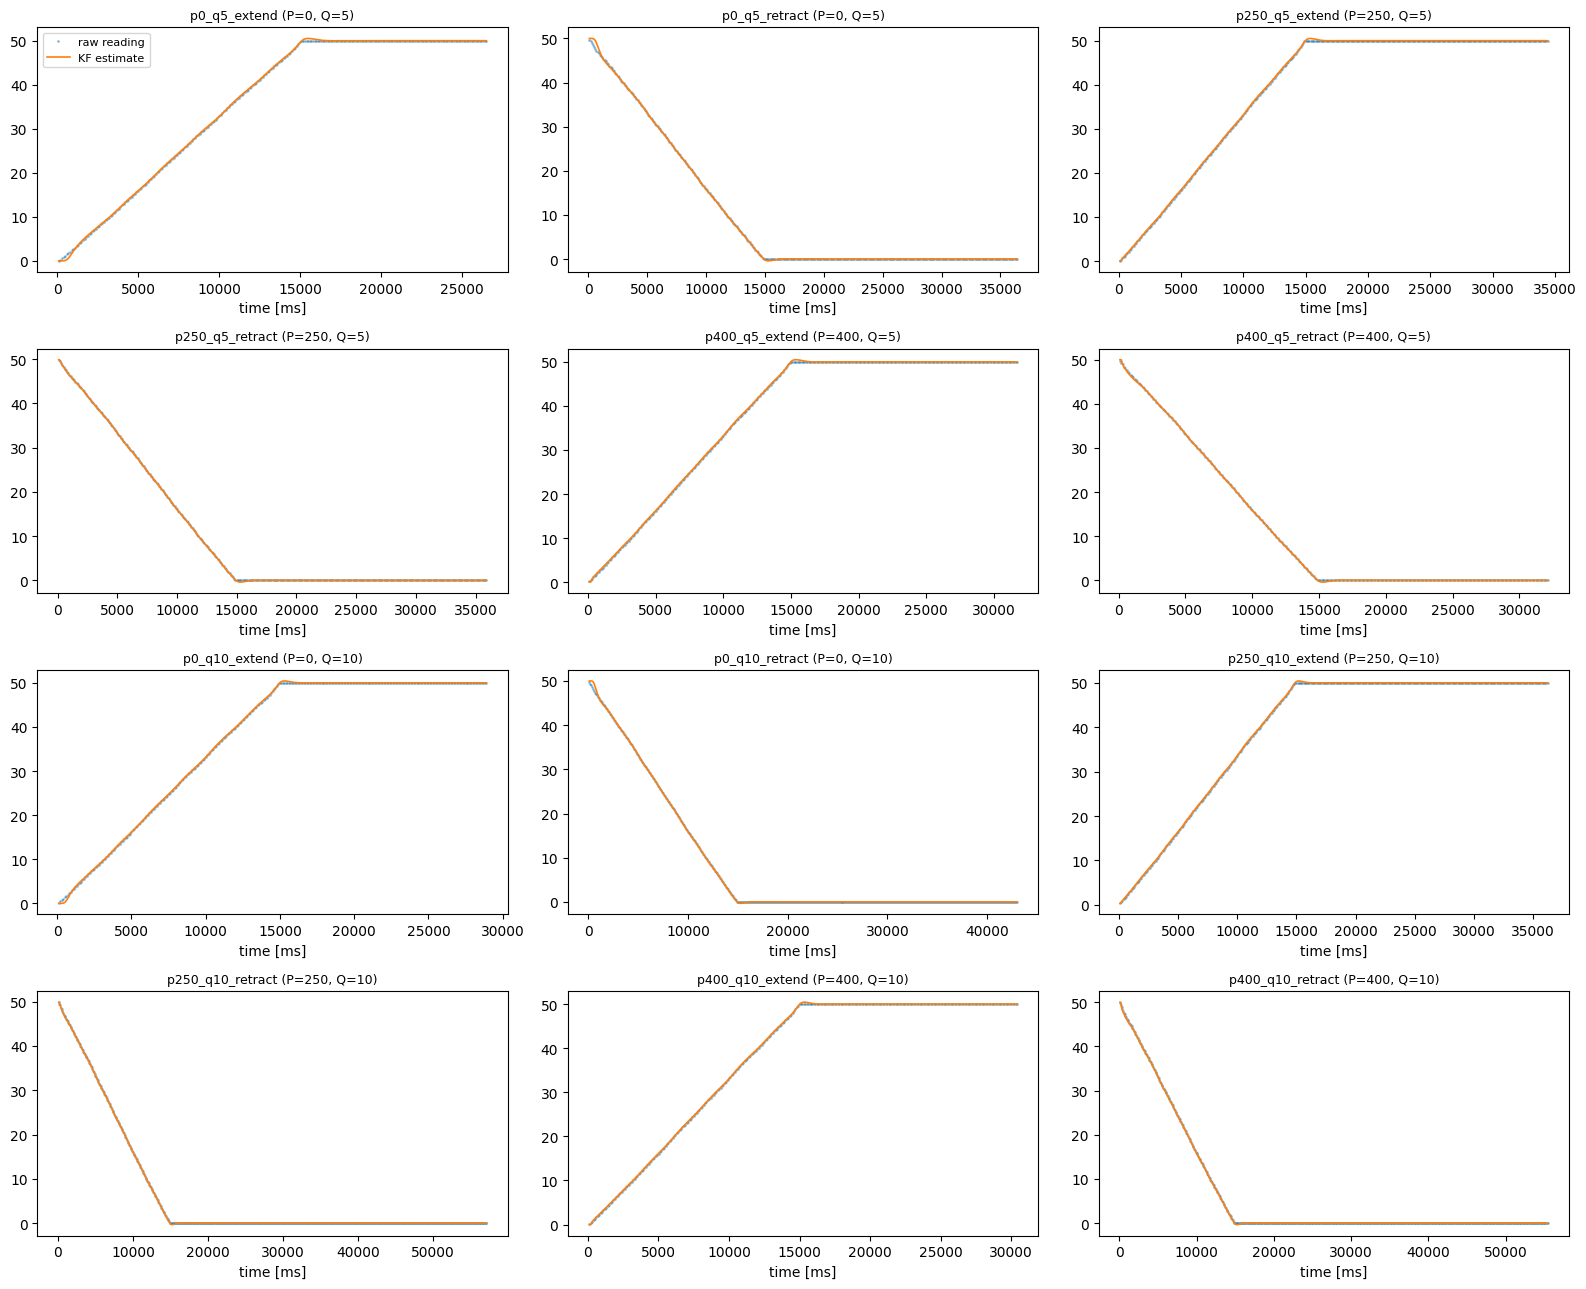

In [4]:
order = ['p0_q5_extend', 'p0_q5_retract', 'p250_q5_extend', 'p250_q5_retract',
         'p400_q5_extend', 'p400_q5_retract', 'p0_q10_extend', 'p0_q10_retract',
         'p250_q10_extend', 'p250_q10_retract', 'p400_q10_extend', 'p400_q10_retract']

fig, axes = plt.subplots(4, 3, figsize=(16, 13))
for ax, name in zip(axes.flat, order):
    df = p_data[name]
    ax.plot(df['time'], df['position_reading'], '.', ms=2, alpha=0.4, label='raw reading')
    ax.plot(df['time'], df['position_estimate'], '-', linewidth=1.2, label='KF estimate')
    ax.set_title(f"{name} (P={P_VALUE_OF[name]:g}, Q={Q_VALUE_OF[name]:g})", fontsize=9)
    ax.set_xlabel('time [ms]')
axes.flat[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

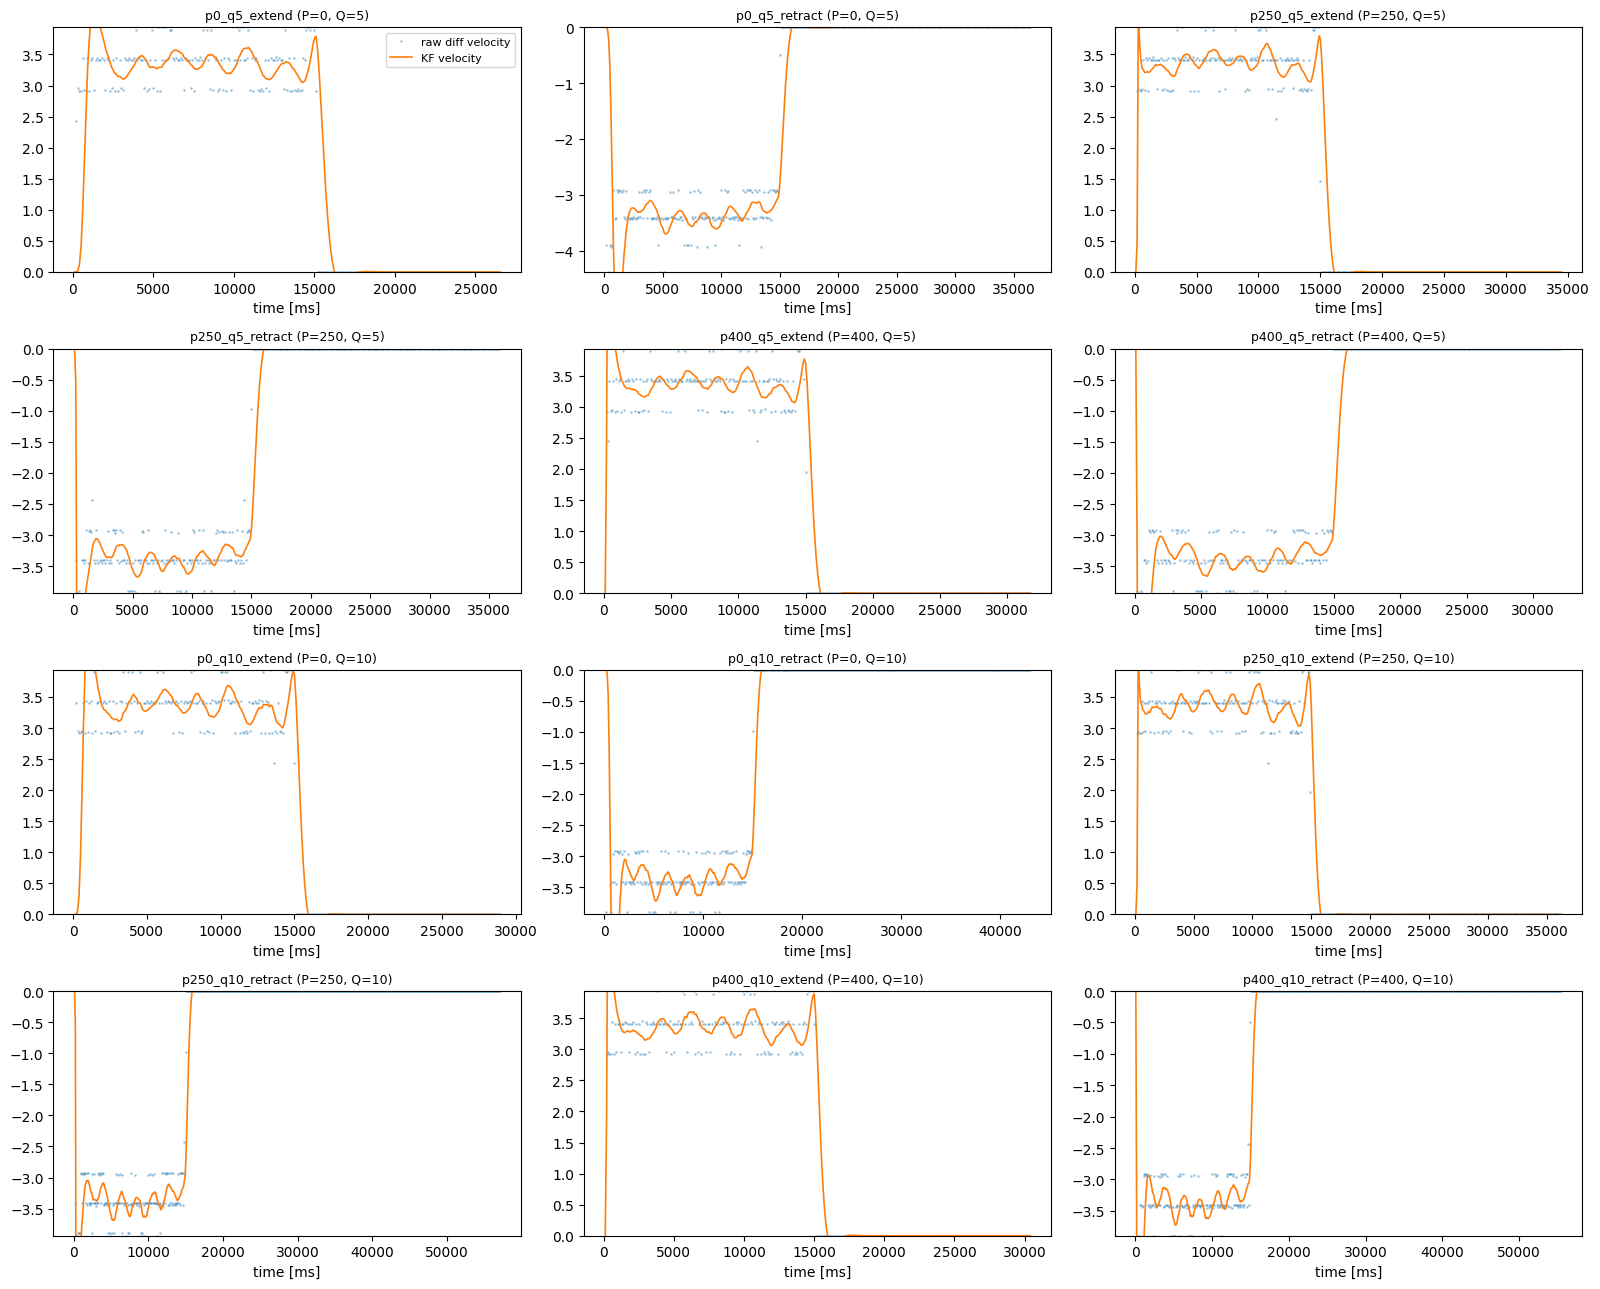

In [5]:
fig, axes = plt.subplots(4, 3, figsize=(16, 13))
for ax, name in zip(axes.flat, order):
    df = p_data[name]
    ax.plot(df['time'], df['raw_velocity'], '.', ms=2, alpha=0.3, label='raw diff velocity')
    ax.plot(df['time'], df['velocity_estimate'], '-', linewidth=1.2, label='KF velocity')
    ax.set_title(f"{name} (P={P_VALUE_OF[name]:g}, Q={Q_VALUE_OF[name]:g})", fontsize=9)
    ax.set_xlabel('time [ms]')
    ax.set_ylim(np.nanpercentile(df['raw_velocity'].dropna(), [1, 99]))
axes.flat[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Automatic verdict: does std trend with P?

In [6]:
def slope_and_monotonic(y_by_p):
    xs = np.array(list(y_by_p.index), dtype=float)
    ys = y_by_p.values.astype(float)
    slope = np.polyfit(xs, ys, 1)[0]
    return slope, y_by_p.is_monotonic_increasing, y_by_p.is_monotonic_decreasing

print("=== Mean resid_std by P, split by Q ===")
for q in q_values:
    trend = p_summary[p_summary['Q (sigma_v_sq)'] == q].groupby('P')['resid_std'].mean().reindex(p_sorted)
    slope, inc, dec = slope_and_monotonic(trend)
    print(f"Q={q:g}: {trend.round(4).to_dict()}  slope={slope:+.5f} /P  monotonic={'inc' if inc else ('dec' if dec else 'no')}")

print("\n=== Mean resid_ac1 by P, split by Q ===")
for q in q_values:
    trend = p_summary[p_summary['Q (sigma_v_sq)'] == q].groupby('P')['resid_ac1'].mean().reindex(p_sorted)
    slope, inc, dec = slope_and_monotonic(trend)
    print(f"Q={q:g}: {trend.round(4).to_dict()}  slope={slope:+.6f} /P  monotonic={'inc' if inc else ('dec' if dec else 'no')}")

print("\n=== Mean vel_est_std by P, split by Q (expected to rise with P: faster strokes) ===")
for q in q_values:
    trend = p_summary[p_summary['Q (sigma_v_sq)'] == q].groupby('P')['vel_est_std'].mean().reindex(p_sorted)
    slope, inc, dec = slope_and_monotonic(trend)
    print(f"Q={q:g}: {trend.round(4).to_dict()}  slope={slope:+.5f} /P  monotonic={'inc' if inc else ('dec' if dec else 'no')}")

print("\nVERDICT:")
overall_resid_std = p_summary.groupby('P')['resid_std'].mean().reindex(p_sorted)
overall_slope, overall_inc, overall_dec = slope_and_monotonic(overall_resid_std)
resid_std_range = overall_resid_std.max() - overall_resid_std.min()
resid_std_rel_range = resid_std_range / overall_resid_std.mean()

if resid_std_rel_range < 0.15 and not (overall_inc or overall_dec):
    print(f"resid_std varies by only {resid_std_rel_range:.1%} across P={p_sorted} and shows no")
    print("consistent monotonic trend -> P does not meaningfully affect estimation/measurement noise.")
    print("-> P is behaving as expected for a setpoint/feedforward gain: it should change how fast")
    print("   the actuator moves, not how noisy the position measurement or KF residual is.")
elif overall_inc or overall_dec:
    direction_word = 'increases' if overall_inc else 'decreases'
    print(f"resid_std {direction_word} monotonically from P={p_sorted[0]} to P={p_sorted[-1]}")
    print(f"(mean slope {overall_slope:+.5f} per unit P, {resid_std_rel_range:.1%} relative range).")
    print("-> There IS a real dependency of noise on P. Likely explanation: higher P drives the")
    print("   actuator harder/faster, which increases mechanical vibration or sensor slew error at")
    print("   the potentiometer, inflating position_reading noise independent of the KF tuning.")
    print("   Consider re-checking R (measurement variance) at each P rather than treating R as")
    print("   fixed across the whole operating range.")
else:
    print(f"resid_std varies by {resid_std_rel_range:.1%} across P but non-monotonically")
    print("-> No clean trend; inspect the table and per-run plots above manually.")

=== Mean resid_std by P, split by Q ===
Q=5: {0.0: 0.203, 250.0: 0.066, 400.0: 0.0864}  slope=-0.00032 /P  monotonic=no
Q=10: {0.0: 0.1595, 250.0: 0.0451, 400.0: 0.0615}  slope=-0.00027 /P  monotonic=no

=== Mean resid_ac1 by P, split by Q ===
Q=5: {0.0: 0.9583, 250.0: 0.9317, 400.0: 0.8514}  slope=-0.000251 /P  monotonic=dec
Q=10: {0.0: 0.9453, 250.0: 0.9014, 400.0: 0.8072}  slope=-0.000328 /P  monotonic=dec

=== Mean vel_est_std by P, split by Q (expected to rise with P: faster strokes) ===
Q=5: {0.0: 1.6853, 250.0: 1.68, 400.0: 1.7929}  slope=+0.00024 /P  monotonic=no
Q=10: {0.0: 1.6725, 250.0: 1.5829, 400.0: 1.6738}  slope=-0.00003 /P  monotonic=no

VERDICT:
resid_std varies by 121.4% across P but non-monotonically
-> No clean trend; inspect the table and per-run plots above manually.
